# Feature Engineering

## Objetivo

Nesta etapa serão desenvolvidas novas variáveis e realizadas transformações nas variáveis existentes com o objetivo de melhorar a capacidade preditiva dos modelos de Machine Learning.

As novas features serão construídas a partir dos insights obtidos durante as etapas de Data Understanding e Exploratory Data Analysis (EDA), buscando representar características relevantes do mercado imobiliário de São Paulo.

As transformações realizadas nesta etapa devem preservar a coerência dos dados e evitar Data Leakage, garantindo que as informações utilizadas pelo modelo estejam disponíveis no momento em que uma nova previsão seria realizada.

## Objetivos específicos

- Avaliar a necessidade de transformação das variáveis numéricas;
- Criar variáveis derivadas das características dos imóveis;
- Representar possíveis diferenças entre imóveis de diferentes padrões;
- Preparar variáveis categóricas para utilização nos modelos;
- Avaliar possíveis interações entre características dos imóveis;
- Evitar a utilização de informações que possam causar Data Leakage.

## Carregamento do dataset limpo

In [14]:
import pandas as pd

df_feat = pd.read_csv(
    "../data/processed/data_cleaned.csv"
)

In [15]:
df_feat.info()

<class 'pandas.DataFrame'>
RangeIndex: 11613 entries, 0 to 11612
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   address   11613 non-null  str  
 1   district  11613 non-null  str  
 2   area      11613 non-null  int64
 3   bedrooms  11613 non-null  int64
 4   garage    11613 non-null  int64
 5   type      11613 non-null  str  
 6   rent      11613 non-null  int64
 7   total     11613 non-null  int64
dtypes: int64(5), str(3)
memory usage: 725.9 KB


## Discussão sobre a criação de features para identificação de imóveis de alto padrão

Durante a etapa de EDA, foi levantada a hipótese de que imóveis de alto padrão poderiam apresentar características distintas dos demais imóveis e, consequentemente, uma variável capaz de representar esse padrão poderia contribuir para a previsão do valor do aluguel.

Inicialmente, foram consideradas diferentes estratégias para representar essa característica.

### 1. Utilização do valor do aluguel

Uma primeira possibilidade seria classificar diretamente os imóveis com maiores valores de `rent` como imóveis de alto padrão. Entretanto, como `rent` é a variável target do projeto, essa abordagem introduziria **Data Leakage**, uma vez que a informação utilizada para criar a feature corresponde diretamente à variável que o modelo deve prever.

Portanto, essa abordagem não será utilizada.

### 2. Utilização do aluguel por metro quadrado

Outra possibilidade considerada foi calcular o valor relativo do aluguel por metro quadrado:

$$
rent\_per\_m^2 = \frac{rent}{area}
$$

Essa métrica pode ser útil para compreender o padrão relativo dos imóveis. Por exemplo, um imóvel com aluguel de R\$ 10.000 e 100 m² apresenta um valor de R\$ 100/m², enquanto um imóvel de R\$ 2.000 e 50 m² apresenta um valor de R\$ 40/m².

Apesar de ser uma métrica interessante para análise exploratória, ela não poderá ser utilizada como feature preditiva, pois depende diretamente da variável `rent`, introduzindo novamente **Data Leakage**.

### 3. Classificação baseada nos bairros

Também foi considerada a possibilidade de classificar os bairros de acordo com seu padrão de valorização e criar uma variável como `district_standard` ou `high_standard_district`.

Essa abordagem seria válida para o modelo, pois o bairro é uma informação disponível no momento da previsão. Entretanto, o dataset possui aproximadamente 1199 bairros distintos, tornando uma classificação manual inviável.

Uma alternativa futura seria enriquecer o dataset com informações externas, como preço médio de aluguel, preço médio do metro quadrado ou indicadores socioeconômicos dos bairros. Essa abordagem, entretanto, exigiria uma fonte externa confiável e compatibilidade temporal entre os dados utilizados. Por esse motivo, essa possibilidade não será implementada inicialmente, mas permanece como uma possibilidade de enriquecimento futuro do projeto.

### 4. Classificação baseada nas características estruturais dos imóveis

Como alternativa, foi considerada a criação de uma medida de padrão estrutural baseada exclusivamente em informações disponíveis no próprio dataset e que estariam disponíveis no momento da previsão.

As principais variáveis consideradas são:

- `area`;
- `bedrooms`;
- `garage`.

A hipótese é que imóveis estruturalmente maiores e mais completos tendem a apresentar características associadas a um padrão superior.

A partir dessas variáveis, será investigada a possibilidade de criar uma pontuação contínua denominada `standard_score`, que represente o padrão estrutural relativo de cada imóvel.

Posteriormente, essa pontuação poderá ser utilizada para criar uma variável categórica ou binária, denominada `high_standard`, classificando os imóveis com maior padrão estrutural.

Uma possibilidade de construção seria padronizar as variáveis e combinar seus z-scores:

$$
Z = \frac{X-\mu}{\sigma}
$$

e então calcular:

$$
standard\_score =
Z_{area} +
Z_{bedrooms} +
Z_{garage}
$$

Uma classificação de alto padrão poderia, por exemplo, considerar os imóveis pertencentes ao percentil superior dessa distribuição.

É importante destacar que `standard_score` e `high_standard` podem ser redundantes dependendo do modelo utilizado. Algoritmos baseados em árvores, como Random Forest e Gradient Boosting, podem aprender diretamente as interações entre `area`, `bedrooms` e `garage`.

Por esse motivo, a criação dessas features será tratada como uma hipótese a ser testada empiricamente.

A contribuição dessas variáveis será posteriormente avaliada comparando modelos com e sem essas features. Caso não proporcionem melhoria no desempenho preditivo, poderão ser removidas do conjunto final de variáveis.

### Conclusão

A investigação realizada demonstrou que existem diferentes formas de representar o conceito de "alto padrão", mas nem todas são adequadas para um modelo preditivo.

A utilização de `rent` ou `rent_per_m^2` apresenta risco de Data Leakage, pois essas variáveis dependem diretamente da variável target. A classificação baseada em bairros é metodologicamente possível, mas exigiria uma etapa adicional de enriquecimento dos dados com fontes externas.

Como alternativa, será investigada uma abordagem baseada exclusivamente nas características estruturais dos imóveis, utilizando `area`, `bedrooms` e `garage`.

A partir dessas variáveis, serão avaliadas duas possíveis novas features:

- `standard_score`: medida contínua do padrão estrutural;
- `high_standard`: classificação binária derivada do `standard_score`.

Essas features serão posteriormente avaliadas durante a etapa de modelagem para determinar se realmente acrescentam poder preditivo ao modelo.

## Criação do `standard_score` global

In [ ]:
# Definindo as variáveis de interesse
standard_features = [
    "area",
    "bedrooms",
    "garage"
]

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_feat[
    ["area_z", "bedrooms_z", "garage_z"]
] = scaler.fit_transform(
    df_feat[standard_features]
)

É ideal que o `StandardScaler` seja ajustado apenas nos dados de treinamento quando chegar a hora da modelagem. Aqui está sendo utilizado apenas para fins de exploração e construção da feature.

In [18]:
df_feat[
    ["area_z", "bedrooms_z", "garage_z"]
].describe()

,area_z,bedrooms_z,garage_z
count,1.161300e+04,1.161300e+04,1.161300e+04
mean,-3.915847e-17,1.370547e-16,1.957924e-17
std,1.000043e+00,1.000043e+00,1.000043e+00
min,-9.443176e-01,-2.116971e+00,-9.385441e-01
25%,-6.064961e-01,-1.042197e+00,-9.385441e-01
50%,-3.362390e-01,3.257733e-02,-5.536505e-02
75%,1.502239e-01,1.107352e+00,8.278140e-01
max,6.690447e+00,4.331674e+00,4.360530e+00


In [19]:
df_feat["standard_score"] = (
    df_feat["area_z"]
    + df_feat["bedrooms_z"]
    + df_feat["garage_z"]
)

In [20]:
df_feat["standard_score"].describe()

count    1.161300e+04
mean     2.349508e-16
std      2.690946e+00
min     -3.945781e+00
25%     -1.839187e+00
50%     -4.941553e-01
75%      1.037641e+00
max      1.511239e+01
Name: standard_score, dtype: float64

In [25]:
df_feat["standard_score"].skew()

np.float64(1.5174548148341895)

In [26]:
df_feat["standard_score"].kurtosis()

np.float64(2.691929201661702)

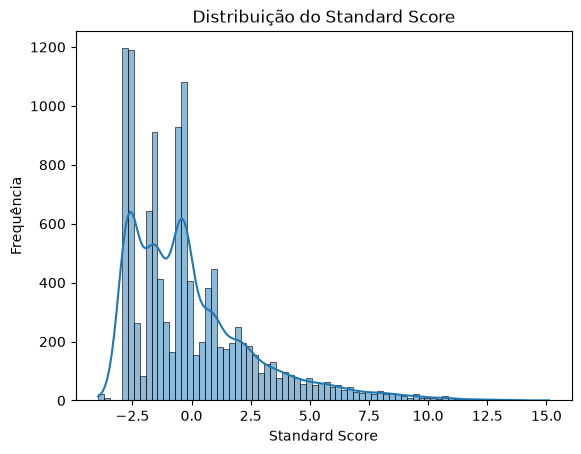

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df_feat,
    x="standard_score",
    kde=True
)

plt.title("Distribuição do Standard Score")
plt.xlabel("Standard Score")
plt.ylabel("Frequência")
plt.show()

In [23]:
df_feat[
    [
        "area",
        "bedrooms",
        "garage",
        "standard_score"
    ]
].sort_values(
    "standard_score",
    ascending=False
).head(20)

,area,bedrooms,garage,standard_score
10197,560,6,6,15.112394
11521,540,6,6,14.842137
10659,540,5,6,13.767363
9086,440,6,6,13.490851
11205,580,5,5,13.424698
9282,512,5,6,13.389003
9864,532,6,4,12.967676
8698,480,5,6,12.956592
10674,540,5,5,12.884184
10353,460,5,6,12.686334


In [24]:
df_feat[
    [
        "area",
        "bedrooms",
        "garage",
        "standard_score"
    ]
].sort_values(
    "standard_score",
    ascending=True
).head(20)

,area,bedrooms,garage,standard_score
4710,19,0,0,-3.945781
96,19,0,0,-3.945781
8207,20,0,0,-3.932268
69,22,0,0,-3.905243
160,22,0,0,-3.905243
7107,22,0,0,-3.905243
1915,22,0,0,-3.905243
2167,25,0,0,-3.864704
1955,25,0,0,-3.864704
3045,26,0,0,-3.851191


### Análise da distribuição do `standard_score` global

A análise descritiva do `standard_score` global mostrou uma média próxima de zero, conforme esperado devido à padronização das variáveis utilizadas em sua construção. O desvio padrão de aproximadamente 2,69 indica uma dispersão considerável entre os imóveis em relação ao padrão estrutural médio do dataset.

A distribuição apresentou skewness de aproximadamente 1,517, indicando assimetria positiva. Esse resultado é coerente com o histograma, que demonstra uma maior concentração de imóveis com scores baixos e intermediários e uma cauda prolongada à direita, associada a uma parcela menor de imóveis com características estruturais significativamente superiores.

A análise dos valores extremos reforçou a coerência da variável criada. O maior `standard_score` observado foi aproximadamente 15,11, associado a um imóvel com 560 m², 6 quartos e 6 vagas de garagem. No extremo oposto, o menor score foi aproximadamente -3,94, correspondente a um imóvel de 19 m², sem quartos e sem vagas de garagem.

Esses resultados indicam que o `standard_score` está capturando de maneira coerente a combinação das características estruturais utilizadas em sua construção (`area`, `bedrooms` e `garage`), diferenciando imóveis estruturalmente menores daqueles que apresentam características significativamente superiores.

## O `standard_score` global tem influencia em relação ao tipo de imóvel?

In [27]:
df_feat.groupby("type")["standard_score"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Apartamento,7187.0,-0.165321,2.037706,-2.925059,-1.568929,-0.440104,0.783312,11.335049
Casa,2829.0,1.517628,3.534855,-2.925059,-1.485437,0.929538,3.792853,15.112394
Casa em condomínio,240.0,1.057440,3.684526,-2.911546,-1.578460,0.113923,2.261057,14.842137
Studio e kitnet,1357.0,-2.475310,0.522773,-3.945781,-2.789930,-2.695340,-1.906751,-0.199288


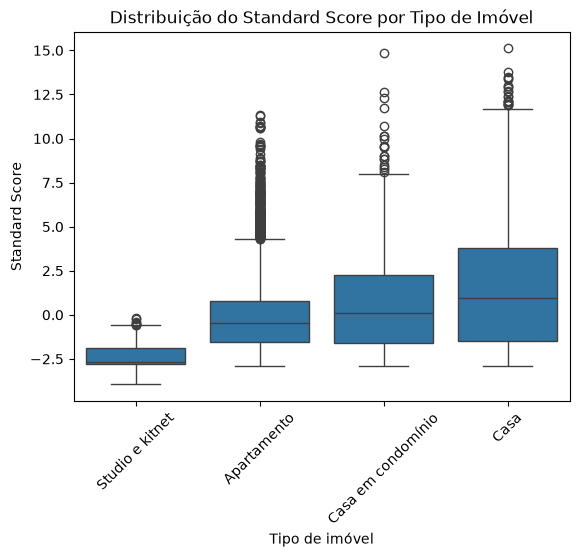

In [28]:
sns.boxplot(
    data=df_feat,
    x="type",
    y="standard_score"
)

plt.xticks(rotation=45)
plt.title("Distribuição do Standard Score por Tipo de Imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Standard Score")
plt.show()

A distribuição do `standard_score` global foi analisada de acordo com o tipo de imóvel para verificar se a métrica apresentava comportamento coerente entre as diferentes categorias.

Os resultados mostraram diferenças claras entre os tipos de imóveis. Os registros classificados como `Studio e kitnet` apresentam os menores valores de `standard_score`, com mediana inferior a zero e baixa dispersão. Esse comportamento é esperado, considerando que esses imóveis tendem a apresentar menores áreas, menor número de quartos e menor quantidade de vagas de garagem.

Os `Apartamentos` apresentam uma distribuição intermediária, com mediana próxima de zero e grande quantidade de valores acima da média, incluindo diversos valores extremos. Já as categorias `Casa em condomínio` e `Casa` apresentam valores centrais mais elevados e maior dispersão, indicando uma maior heterogeneidade nas características estruturais desses imóveis.

A categoria `Casa` concentra os maiores valores de `standard_score`, enquanto `Studio e kitnet` concentra os menores. Esse comportamento é coerente com as características utilizadas para construir o score (`area`, `bedrooms` e `garage`) e indica que a variável está capturando diferenças estruturais esperadas entre os tipos de imóveis.

Dessa forma, optou-se por manter o `standard_score` como uma medida global do padrão estrutural do imóvel. A intenção é identificar imóveis estruturalmente superiores em relação ao conjunto total de dados, e não classificar um imóvel como de alto padrão apenas em comparação com outros imóveis pertencentes ao mesmo tipo.

In [29]:
threshold = df_feat["standard_score"].quantile(0.90)

df_feat["high_standard"] = (
    df_feat["standard_score"] >= threshold
).astype(int)

In [30]:
pd.crosstab(
    df_feat["type"],
    df_feat["high_standard"],
    normalize="index"
) * 100

high_standard,0,1
type,,
Apartamento,94.684848,5.315152
Casa,73.948392,26.051608
Casa em condomínio,82.083333,17.916667
Studio e kitnet,100.000000,0.000000


### Validação da variável `high_standard`

Após a criação do `standard_score`, foi definida inicialmente uma classificação de `high_standard` considerando os imóveis pertencentes ao percentil 90 superior da distribuição do score.

A análise mostrou que a classificação resultou em uma parcela relativamente pequena de imóveis considerados de alto padrão, conforme esperado. Entretanto, a distribuição da classificação entre os tipos de imóveis revelou uma forte associação entre `high_standard` e `type`.

Aproximadamente 26,05% das casas foram classificadas como alto padrão, enquanto 17,92% das casas em condomínio e 5,32% dos apartamentos receberam essa classificação. Nenhum imóvel classificado como `Studio e kitnet` foi considerado de alto padrão segundo esse critério.

Esse resultado é coerente com a construção do `standard_score`, uma vez que a variável é baseada em `area`, `bedrooms` e `garage`, características que apresentam diferenças estruturais naturais entre os tipos de imóveis. Dessa forma, o `high_standard` criado representa uma classificação de padrão estrutural **global**, identificando os 10% de imóveis com maiores combinações de área, quartos e garagens no conjunto de dados. Portanto, **não se trata de uma classificação relativa ao tipo do imóvel**.

A análise também evidencia uma limitação da abordagem: o `high_standard` apresenta forte associação com a variável `type` e pode, portanto, carregar informações parcialmente redundantes com as próprias variáveis utilizadas para sua construção. Por esse motivo, a utilidade preditiva de `standard_score` e `high_standard` deverá ser avaliada posteriormente durante a etapa de modelagem, comparando o desempenho dos modelos com e sem essas features.

## E se o `standard_score` fosse calculado para cada tipo de imóvel independentemente?

Durante a análise do `standard_score` global, observou-se uma forte associação entre o score e o tipo de imóvel. Studios e kitnets apresentaram sistematicamente os menores valores, enquanto casas e casas em condomínio concentraram os maiores scores. Esse comportamento é esperado, uma vez que a variável foi construída a partir de características estruturais (`area`, `bedrooms` e `garage`) que apresentam distribuições naturalmente diferentes entre os tipos de imóveis.

Essa observação levanta uma nova hipótese: um imóvel pode apresentar características estruturais superiores em relação a outros imóveis do **mesmo tipo**, mesmo que não seja considerado estruturalmente grande quando comparado com todo o conjunto de dados. Por exemplo, um studio de 60 m² pode apresentar uma área elevada em comparação com outros studios, mas ainda possuir um `standard_score` global baixo quando comparado com casas de grandes dimensões.

Para capturar essa informação relativa, será criada uma nova variável denominada `standard_score_type`

### Limitações e cuidados metodológicos

O `standard_score_type` foi criado inicialmente como uma feature exploratória, com o objetivo de investigar se o padrão estrutural relativo ao tipo de imóvel apresenta informações complementares ao padrão estrutural global.

Na etapa exploratória, as estatísticas de padronização são calculadas utilizando todo o dataset. Entretanto, essa abordagem não deve ser utilizada diretamente na avaliação final dos modelos, pois as médias e desvios padrão calculados a partir de todo o conjunto de dados podem incorporar informações provenientes do conjunto de teste.

In [31]:
from scipy.stats import zscore

df_feat["standard_score_type"] = (
    df_feat
    .groupby("type")[["area", "bedrooms", "garage"]]
    .transform(zscore)
    .sum(axis=1)
)

In [32]:
df_feat.groupby("type")["standard_score_type"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Apartamento,7187.0,-6.327360e-17,2.621274,-3.536810,-1.790338,-0.398685,1.130709,15.573097
Casa,2829.0,4.018623e-16,2.697321,-3.406632,-2.281280,-0.408952,1.758027,10.357986
Casa em condomínio,240.0,0.000000e+00,2.810409,-3.064362,-2.002708,-0.682591,1.014828,10.486189
Studio e kitnet,1357.0,-4.712516e-16,1.954357,-6.802830,-1.269941,-0.509159,1.211081,9.669677


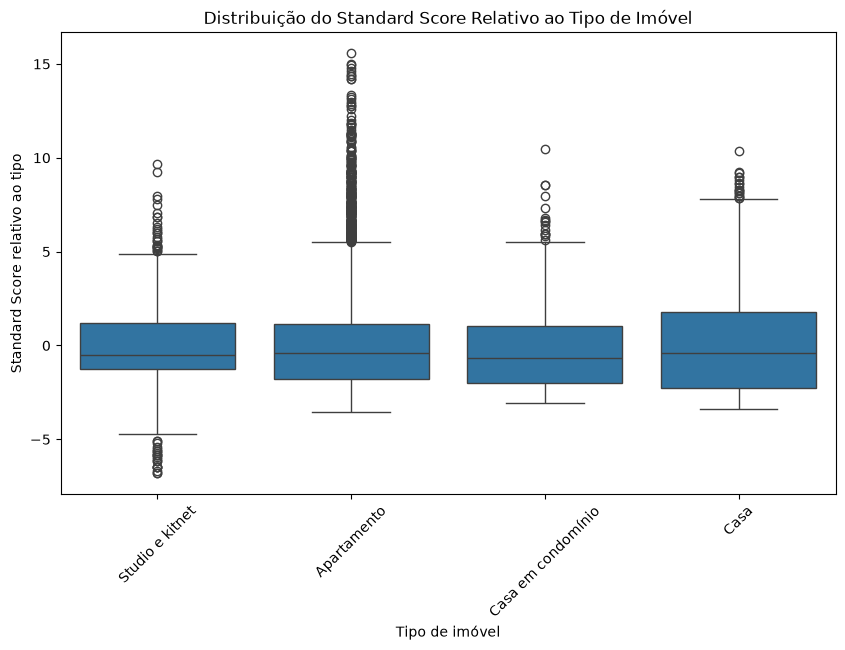

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_feat,
    x="type",
    y="standard_score_type"
)

plt.xticks(rotation=45)
plt.title("Distribuição do Standard Score Relativo ao Tipo de Imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Standard Score relativo ao tipo")

plt.show()

### Análise do `standard_score_type`

A distribuição do `standard_score_type` foi analisada para verificar se a padronização das características estruturais dentro de cada tipo de imóvel permitiria identificar imóveis relativamente superiores em suas respectivas categorias.

Diferentemente do `standard_score` global, observou-se uma redução significativa das diferenças entre os tipos de imóveis. Enquanto o score global apresentava uma separação clara entre `Studio e kitnet`, `Apartamento`, `Casa em condomínio` e `Casa`, o score relativo ao tipo apresenta distribuições mais próximas entre as categorias.

Esse resultado indica que o `standard_score_type` captura uma dimensão diferente do padrão estrutural. Enquanto o `standard_score` global representa a posição estrutural do imóvel em relação a todo o dataset, o `standard_score_type` representa sua posição relativa em comparação com imóveis pertencentes ao mesmo tipo.

Essa diferença permite identificar situações que não eram capturadas pelo score global. Um `Studio e kitnet`, por exemplo, pode apresentar um `standard_score` global relativamente baixo devido às características estruturais menores esperadas para essa categoria, mas apresentar um `standard_score_type` elevado caso esteja entre os imóveis estruturalmente superiores dentro de seu tipo.

A presença de valores elevados de `standard_score_type` em todas as categorias reforça essa interpretação. Dessa forma, a variável pode ser utilizada como uma medida de padrão estrutural relativo, permitindo comparar imóveis considerando as características esperadas para cada tipo de propriedade. Além disso, a análise também mostrou que `Apartamento` apresenta uma quantidade expressiva de valores extremos superiores, enquanto `Casa` apresenta maior dispersão em sua distribuição central. Essas diferenças indicam que as categorias possuem diferentes níveis de heterogeneidade estrutural, mesmo após a padronização relativa ao tipo.

Portanto, o `standard_score_type` será mantido como uma feature candidata para as etapas posteriores de modelagem, sendo posteriormente avaliado em conjunto com o `standard_score` global para verificar se as duas variáveis fornecem informações complementares para a previsão do aluguel.

In [34]:
threshold_type = (
    df_feat
    .groupby("type")["standard_score_type"]
    .transform("quantile", 0.90)
)

In [35]:
df_feat["high_standard_type"] = (
    df_feat["standard_score_type"] >= threshold_type
).astype(int)

In [36]:
pd.crosstab(
    df_feat["type"],
    df_feat["high_standard_type"]
)

high_standard_type,0,1
type,,
Apartamento,6467,720
Casa,2545,284
Casa em condomínio,216,24
Studio e kitnet,1214,143


### Criação do `high_standard_type`

A análise do `high_standard` global mostrou que nenhum imóvel classificado como `Studio e kitnet` foi considerado de alto padrão. Esse resultado ocorre porque a classificação global compara imóveis de diferentes tipos, fazendo com que características estruturais naturalmente maiores de casas e apartamentos dominem os maiores valores de `standard_score`.

Para investigar uma definição alternativa de alto padrão, foi criada a variável `high_standard_type`, baseada no `standard_score_type`. Nesse caso, cada imóvel é comparado apenas com outros imóveis pertencentes ao mesmo tipo. Foram classificados como `high_standard_type = 1` os imóveis pertencentes ao percentil 90 superior do `standard_score_type` dentro de sua respectiva categoria.

Dessa forma, a variável representa uma classificação de alto padrão estrutural relativo ao tipo do imóvel.

A interpretação das duas variáveis é, portanto, distinta:

- `high_standard`: identifica os 10% de imóveis estruturalmente superiores considerando todo o dataset;
- `high_standard_type`: identifica os 10% de imóveis estruturalmente superiores dentro de cada tipo de imóvel.

Essa abordagem permite identificar, por exemplo, um `Studio e kitnet` que apresente características estruturais superiores em relação aos demais studios e kitnets, mesmo que suas características absolutas sejam menores quando comparadas às de casas ou apartamentos.

As duas variáveis serão mantidas como features candidatas e sua contribuição individual e conjunta deverá ser avaliada posteriormente durante a etapa de modelagem.

In [38]:
df_feat.head()

,address,district,area,bedrooms,garage,type,rent,total,area_z,bedrooms_z,garage_z,standard_score,high_standard,standard_score_type,high_standard_type
0,Rua Herval,Belenzinho,21,1,0,Studio e kitnet,2400,2939,-0.863240,-1.042197,-0.938544,-2.843981,0,-1.704674,0
1,Avenida São Miguel,Vila Marieta,15,1,1,Studio e kitnet,1030,1345,-0.944318,-1.042197,-0.055365,-2.041880,0,-0.201800,0
2,Rua Oscar Freire,Pinheiros,18,1,0,Apartamento,4000,4661,-0.903779,-1.042197,-0.938544,-2.884520,0,-3.477777,0
3,Rua Júlio Sayago,Vila Ré,56,2,2,Casa em condomínio,1750,1954,-0.390290,0.032577,0.827814,0.470101,0,-0.372601,0
4,Rua Barata Ribeiro,Bela Vista,19,1,0,Studio e kitnet,4000,4654,-0.890266,-1.042197,-0.938544,-2.871007,0,-1.922040,0


## Conclusão da Feature Engineering

Inicialmente, foi definido `rent` como a variável target do problema. A variável `total` não foi utilizada na criação de novas features preditivas, uma vez que apresenta forte relação direta com o aluguel e poderia introduzir data leakage.

A partir das características estruturais disponíveis no dataset, foram desenvolvidas quatro features candidatas:

- `standard_score`: representa o padrão estrutural absoluto do imóvel, considerando conjuntamente sua área, número de quartos e número de vagas de garagem em relação ao conjunto total de dados;
- `standard_score_type`: representa o padrão estrutural relativo do imóvel em comparação com outros imóveis do mesmo tipo;
- `high_standard`: classificação binária dos 10% de imóveis com maiores `standard_score`;
- `high_standard_type`: classificação binária dos 10% de imóveis com maiores `standard_score_type` dentro de cada categoria de imóvel.

A criação das duas versões do score surgiu da observação de que o `standard_score` global apresentava forte associação com a variável `type`. Embora esse comportamento fosse coerente com as diferenças estruturais entre casas, apartamentos e studios, levantou-se a hipótese de que um imóvel poderia apresentar características superiores dentro de sua própria categoria sem necessariamente apresentar características absolutas superiores em relação a todo o dataset.

Dessa forma, foram mantidas as versões global e relativa ao tipo como features candidatas. A contribuição individual e conjunta dessas variáveis deverá ser avaliada posteriormente durante a etapa de modelagem.